In [1]:
import scarf
from scarf.plotting import CellField, ColorScale, FeatureRef

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
graph = run["connectivity_map"]

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

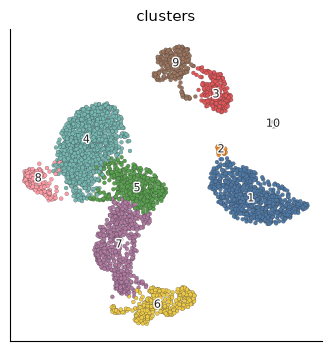

In [2]:
ds.plots.embedding(run=run, layout="umap", color_by="clusters", legend_loc="on_data")

In [3]:
diffusion = ds.run_diffusion_operator(graph)
smoothed = ds.get_imputed(feature_name="CD4", diffusion=diffusion)
ds.cells.insert("CD4_imputed_t2", smoothed, key="I", overwrite=True)

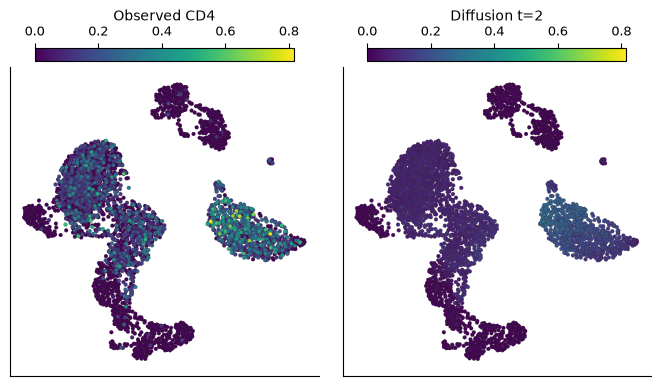

In [4]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=[
        FeatureRef("CD4", label="Observed CD4"),
        CellField("CD4_imputed_t2", kind="continuous", label="Diffusion t=2"),
    ],
    n_columns=2,
    color_scale=ColorScale(scope="shared"),
    sort_values=True,
)

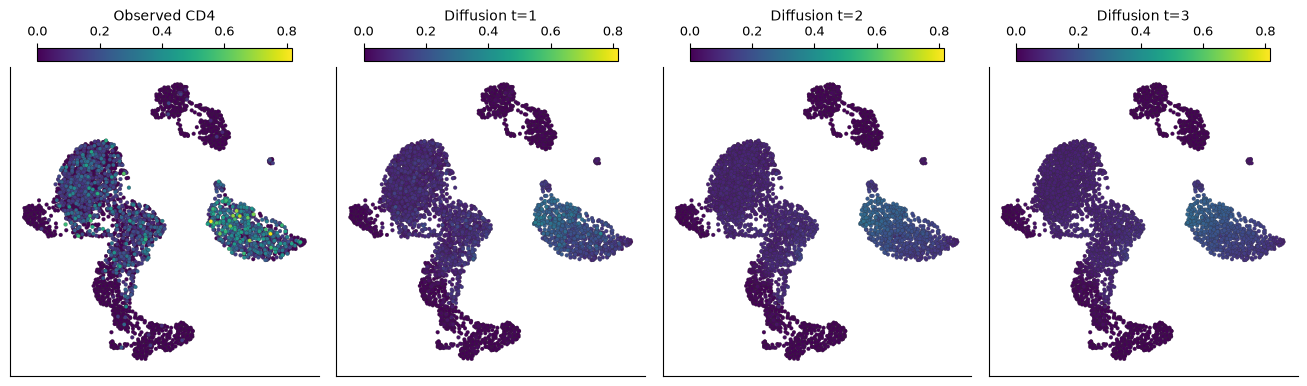

In [5]:
for t in (1, 3):
    operator = ds.run_diffusion_operator(graph, t=t)
    values = ds.get_imputed(feature_name="CD4", diffusion=operator)
    ds.cells.insert(f"CD4_imputed_t{t}", values, key="I", overwrite=True)

ds.plots.embedding(
    layout=run["umap"],
    color_by=[FeatureRef("CD4", label="Observed CD4")]
    + [
        CellField(f"CD4_imputed_t{t}", kind="continuous", label=f"Diffusion t={t}")
        for t in (1, 2, 3)
    ],
    n_columns=4,
    color_scale=ColorScale(scope="shared"),
    sort_values=True,
)